In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely
import zipfile

In [2]:
iso3 = 'SOM'
from_crs = 'epsg:4326'
to_crs = 'epsg:20539'

In [3]:
gdfs = {}

In [4]:
gdfs['adm'] = gpd.read_file('/data/big/fmalveiro/complexity72/gadm41_SOM_2.json.zip')

In [5]:
dfs = {}

with zipfile.ZipFile('/data/big/fmalveiro/complexity72/AfricaUrbanNetwork.zip') as zfile:
    for key in ('nodes', 'edges'):
        with zfile.open(f"AfricaNetwork{key.title()}.csv") as file:
            dfs[key] = pd.read_csv(file, encoding='iso-8859-1')

In [6]:
country_dfs = {}

# select nodes in country
useful_nodes = set(dfs['nodes'][dfs['nodes']['ISO3'] == iso3]['Agglomeration_ID'])
country_dfs['nodes'] = dfs['nodes'][dfs['nodes']['Agglomeration_ID'].isin(useful_nodes)]

# select edges linked to those nodes
country_dfs['edges'] = dfs['edges'][dfs['edges']['from'].isin(useful_nodes) | dfs['edges']['to'].isin(useful_nodes)]

# include nodes in edges above that may be outside country
linked_nodes = set(country_dfs['edges'][['from', 'to']].to_numpy().flatten())

useful_nodes = useful_nodes.union(linked_nodes)
country_dfs['nodes'] = dfs['nodes'][dfs['nodes']['Agglomeration_ID'].isin(useful_nodes)]

In [7]:
gdfs['nodes'] = gpd.GeoDataFrame(
    pd.concat((
        country_dfs['nodes']['Agglomeration_ID'],
        gpd.GeoSeries(country_dfs['nodes'][['x', 'y']].apply(lambda x: shapely.Point(x['x'], x['y']), axis=1), crs=from_crs, name='geometry'))
   , axis=1)
)

In [8]:
gdfs['edges'] = gpd.GeoDataFrame(
    pd.concat((
        country_dfs['edges'][['from', 'to']],
        gpd.GeoSeries(
            country_dfs['edges'][['from', 'to']].apply(lambda x: shapely.LineString(
            [
                gdfs['nodes'][gdfs['nodes']['Agglomeration_ID'] == x['from']].iloc[0]['geometry'], 
                gdfs['nodes'][gdfs['nodes']['Agglomeration_ID'] == x['to']].iloc[0]['geometry']
            ]), axis=1),
            crs=from_crs, name='geometry')
    ), axis=1)
)

In [9]:
proj_gdfs = {key: value.to_crs(to_crs) for key, value in gdfs.items()}
proj_gdfs['adm']['centroid'] = proj_gdfs['adm'].centroid

In [10]:
country_dfs['nodes'].columns

Index(['Agglomeration_ID', 'agglosName', 'x', 'y', 'Pop2015', 'ISO3', 'Region',
       'Between', 'degree'],
      dtype='object')

Text(0.5, 1.0, '29 nodes, 27 edges')

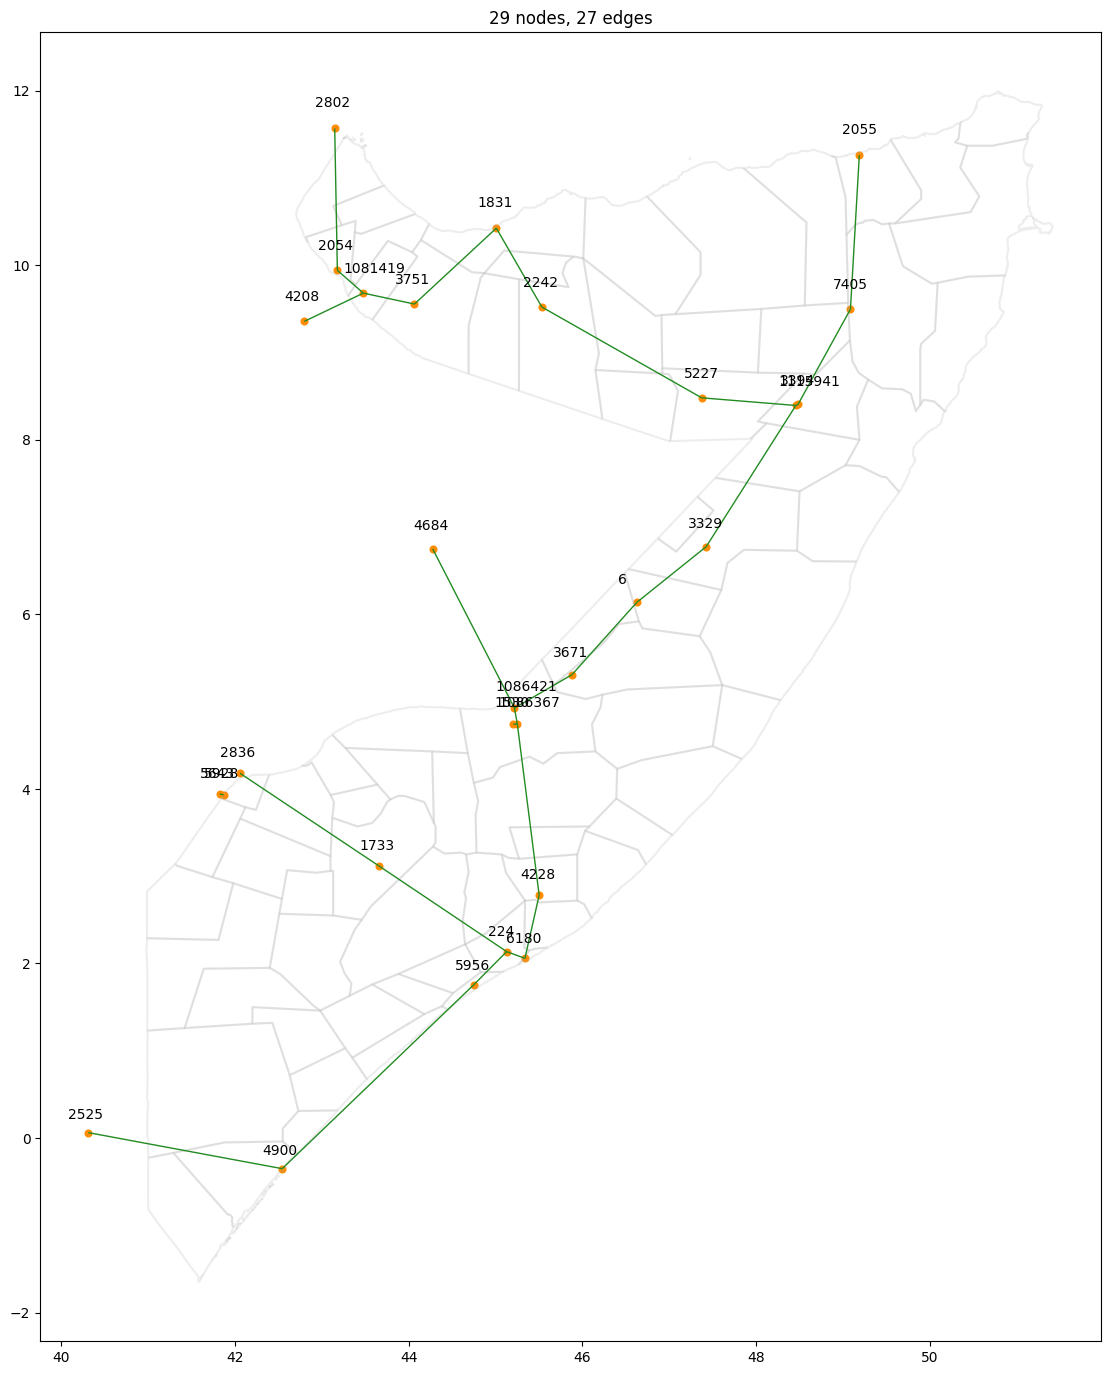

In [11]:
plot_adm = True

fig, ax = plt.subplots(1, figsize=(17,17))

if plot_adm:
    gdfs['adm'].boundary.plot(ax=ax, color='darkgrey', alpha=.2)

gdfs['nodes'].plot(ax=ax, markersize=23, color='darkorange')
gdfs['edges'].plot(ax=ax, linewidth=1, color='forestgreen')

for idx, row in gdfs['nodes'].iterrows():
    x = row['geometry'].x
    y = row['geometry'].y
    ax.annotate(row['Agglomeration_ID'], xy=(x, y), xytext=(-25+x/4,10+y/2), xycoords='data', textcoords='offset points')

ax.set_title(f"{gdfs['nodes'].shape[0]} nodes, {gdfs['edges'].shape[0]} edges")

Text(0.5, 0.93, 'Population values provided in the dataframe')

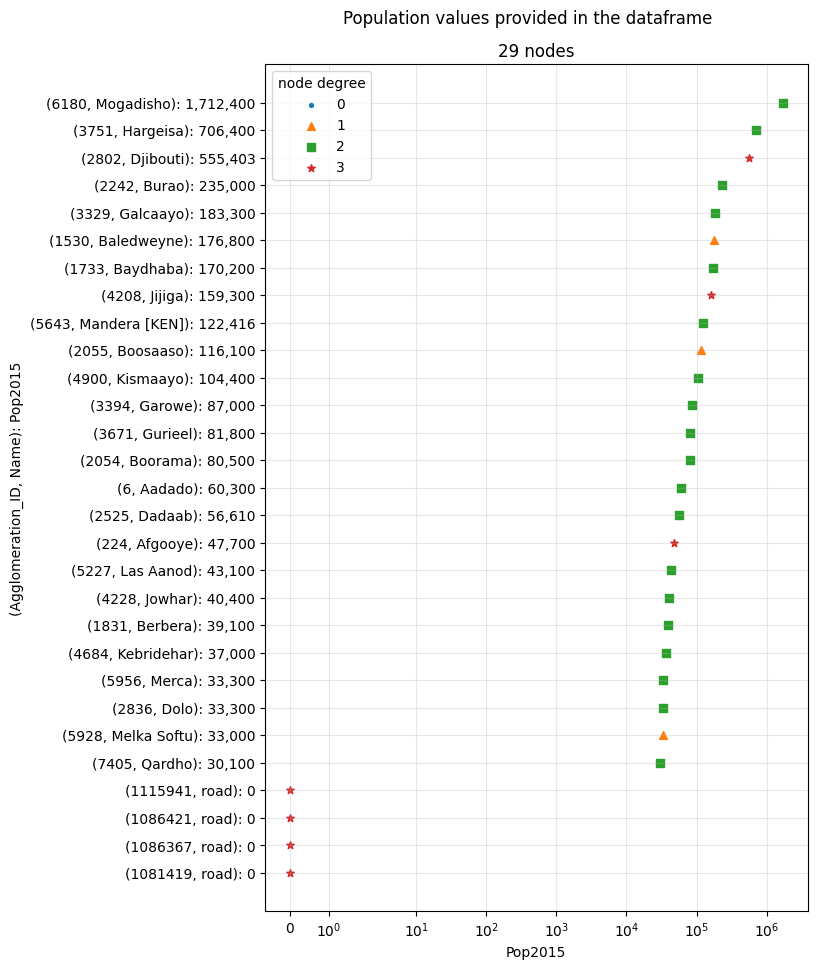

In [12]:
marker_map = {0: '.', 1: '^', 2: 's', 3: '*'}

fig, ax = plt.subplots(1, figsize=(7, 11))

filter_df = country_dfs['nodes'][country_dfs['nodes']['Agglomeration_ID'].isin(useful_nodes)]
x = filter_df['Pop2015'].sort_values(ascending=True)
y = pd.Series(np.arange(gdfs['nodes'].shape[0]), index=x.index)

labels = filter_df.loc[x.index][['Agglomeration_ID', 'agglosName', 'Pop2015']].apply(
    lambda x: f"({x['Agglomeration_ID']}, {x['agglosName']}): {x['Pop2015']:,}", axis=1
)
markers = filter_df.loc[x.index]['degree'].map(marker_map)

for key, value in marker_map.items():
    mask = markers[markers == value].index
    marker_x = x.loc[mask]
    marker_y = y.loc[mask]
    ax.scatter(marker_x, marker_y, marker=value, s=31, label=key)

ax.set_ylabel('(Agglomeration_ID, Name): Pop2015')
ax.set_xlabel('Pop2015')

ax.set_xscale('symlog')
ax.set_yticks(y, labels=labels)

ax.legend(title='node degree')

ax.grid('on', alpha=.3)
ax.set_title(f"{x.size} nodes")
fig.suptitle('Population values provided in the dataframe', y=.93)

What is the distance of each administrative region to the closest node in the network?

In [13]:
nearest = gpd.sjoin_nearest(
    proj_gdfs['adm'][['centroid']].set_geometry('centroid'), 
    proj_gdfs['nodes'],
    distance_col='distance'
)

nearest = pd.merge(nearest, filter_df[['Agglomeration_ID', 'agglosName']], on='Agglomeration_ID', how='left')
nearest = pd.merge(nearest, gdfs['adm']['NAME_2'], how='left', left_index=True, right_index=True)

Text(0.5, 0.93, 'Distance from centroid of adm region to closest node')

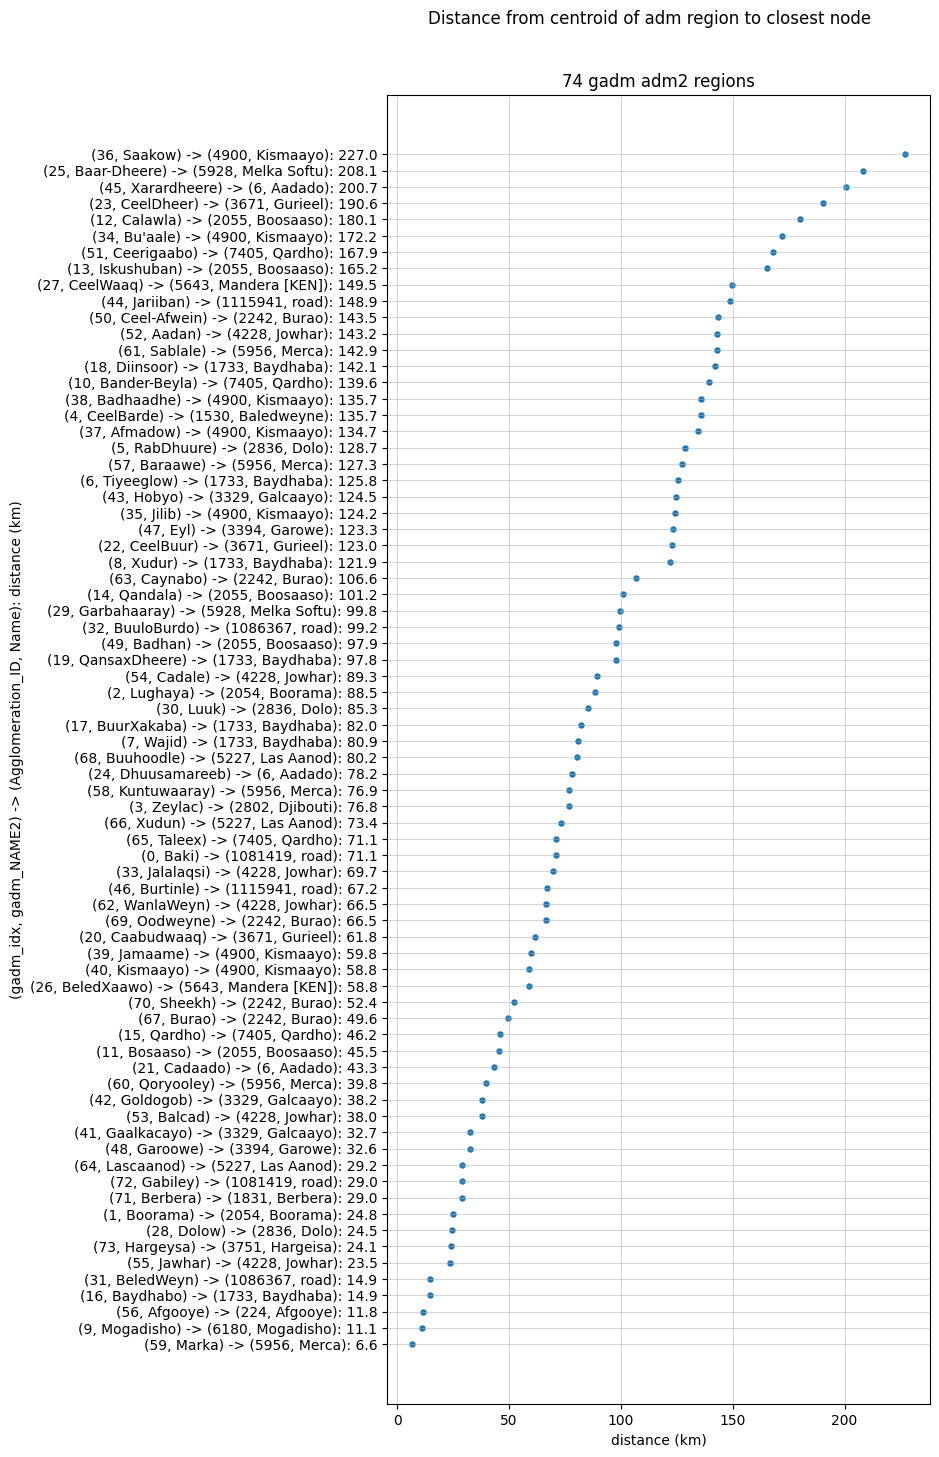

In [14]:
fig, ax = plt.subplots(1, figsize=(7, 17))

x = (nearest['distance'] * 1e-3).sort_values(ascending=True)
y = pd.Series(np.arange(x.size), index=x.index)

labels = nearest.loc[x.index][['Agglomeration_ID', 'distance', 'agglosName', 'NAME_2']].reset_index(drop=False).apply(
    lambda x: f"({x['index']}, {x['NAME_2']}) -> ({x['Agglomeration_ID']}, {x['agglosName']}): {x['distance']*1e-3:.1f}", axis=1
)

ax.scatter(x, y, s=13)

ax.set_yticks(y, labels=labels)

ax.set_xlabel('distance (km)')
ax.set_ylabel('(gadm_idx, gadm_NAME2) -> (Agglomeration_ID, Name): distance (km)')

ax.grid('on', alpha=.5)

ax.set_title(f"{x.size} gadm adm2 regions")
fig.suptitle('Distance from centroid of adm region to closest node', y=.93)

In [15]:
nearest['edge_geometry'] = gpd.GeoSeries(
    pd.merge(
        nearest[['Agglomeration_ID', 'centroid']].rename({'centroid': 'geometry'}, axis=1), proj_gdfs['nodes'][['Agglomeration_ID', 'geometry']], 
        how='left', on='Agglomeration_ID', suffixes=('_net', '_adm')
    ).apply(lambda x: shapely.LineString([x['geometry_net'], x['geometry_adm']]), axis=1), crs=to_crs)

In [16]:
degree = pd.merge(
        nearest['Agglomeration_ID'].value_counts().reset_index(drop=False, name='count'),
        country_dfs['nodes'][['Agglomeration_ID', 'agglosName']], 
        how='left', on='Agglomeration_ID'
    )

Text(0.5, 1.0, '25 nodes')

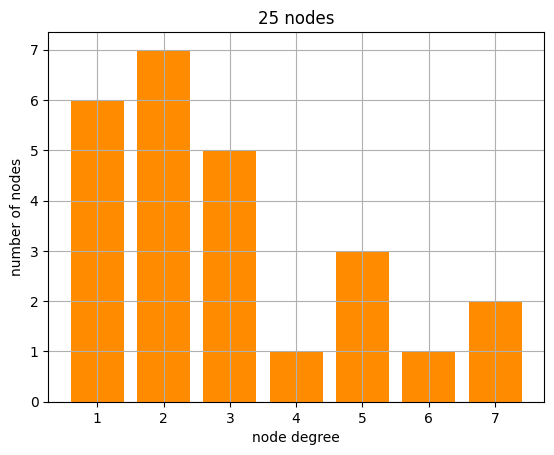

In [20]:
vector = degree['count'].value_counts(dropna=False).sort_index(ascending=True)

fig, ax = plt.subplots(1)

ax.bar(vector.index, vector.to_numpy(), color='darkorange')

ax.set_xlabel('node degree')
ax.set_ylabel('number of nodes')

ax.grid('on')
ax.set_title(f"{degree.shape[0]} nodes")

Text(0.5, 1.0, '74 adm2 regions; 29 nodes, 27 edges in the network')

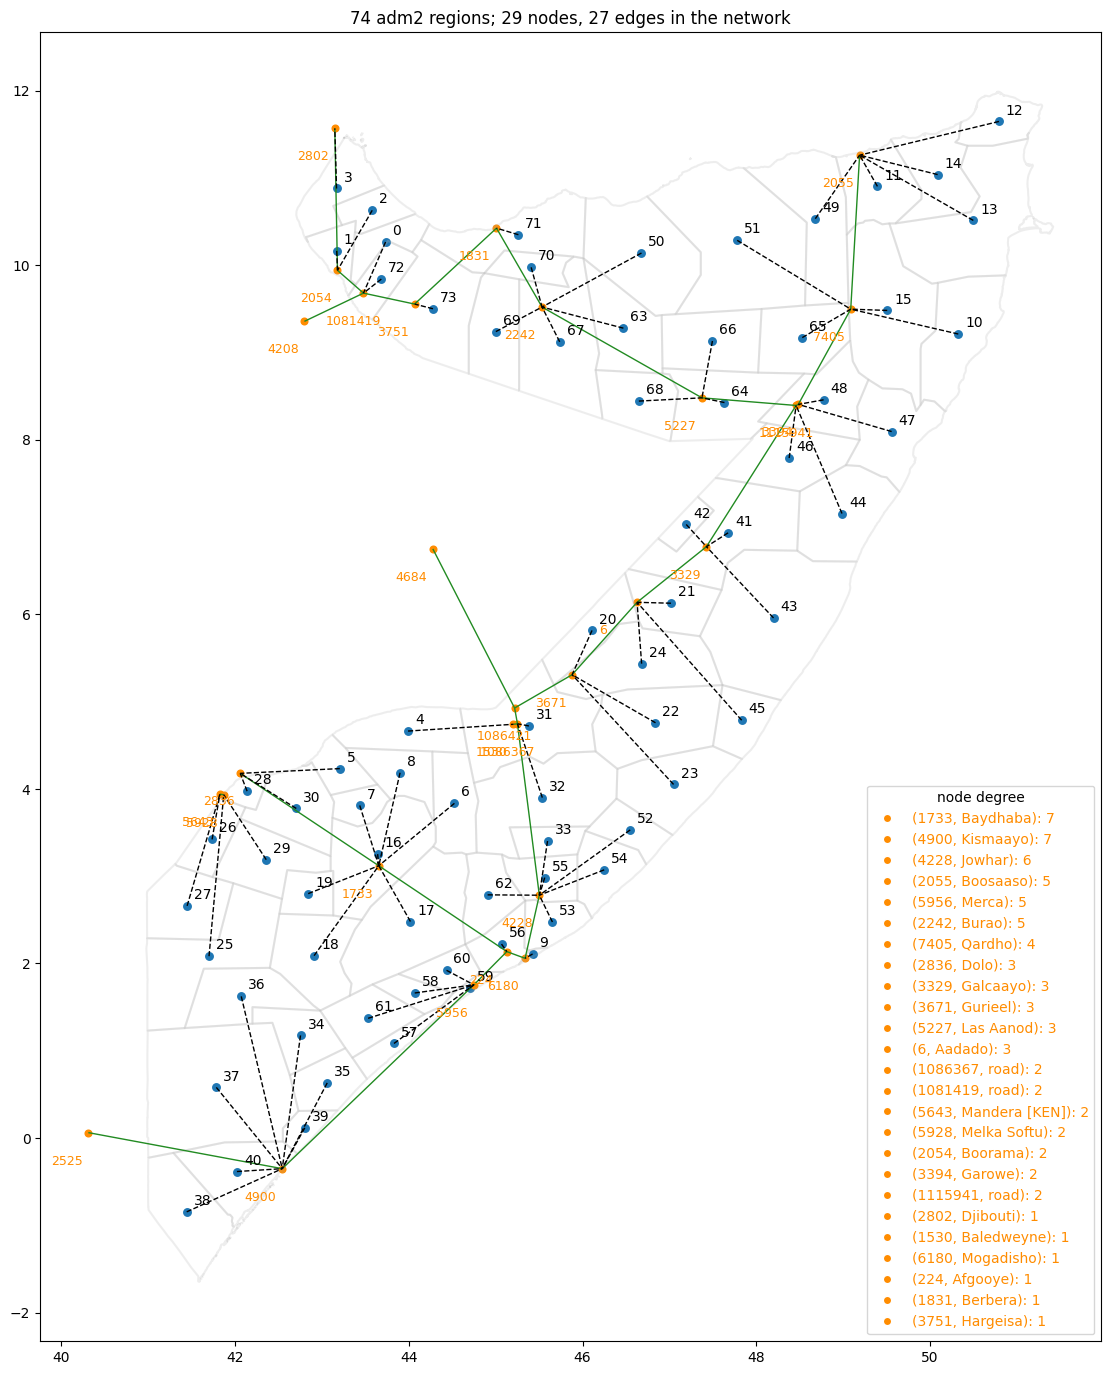

In [22]:
fig, ax = plt.subplots(1, figsize=(17,17))

gdfs['adm'].boundary.plot(ax=ax, color='darkgrey', alpha=.2)
proj_gdfs['adm']['centroid'].to_crs(from_crs).plot(ax=ax, markersize=29)

gdfs['nodes'].plot(ax=ax, markersize=23, color='darkorange')
gdfs['edges'].plot(ax=ax, linewidth=1, color='forestgreen')

nearest[['edge_geometry']].set_geometry('edge_geometry').to_crs(from_crs).plot(ax=ax, linewidth=1, linestyle='--', edgecolor='k')

# annotate adm regions
for idx, row in nearest.set_geometry('centroid').to_crs(from_crs).reset_index(names='gadm_idx').iterrows():
    x = row['centroid'].x
    y = row['centroid'].y
    ax.annotate(row['gadm_idx'], xy=(x, y), xytext=(5,5), xycoords='data', textcoords='offset points')

# annotate network nodes
for idx, row in gdfs['nodes'].iterrows():
    x = row['geometry'].x
    y = row['geometry'].y
    ax.annotate(row['Agglomeration_ID'], xy=(x, y), xytext=(-27,-23), xycoords='data', textcoords='offset points', color='darkorange', size=9)


ax.legend(
    handles=list(map(lambda x: mpl.lines.Line2D([], [], color='white', marker='o', markerfacecolor='darkorange', label=x), degree.apply(lambda x: f"({x['Agglomeration_ID']}, {x['agglosName']}): {x['count']}", axis=1).tolist()
)), title='node degree', labelcolor='markerfacecolor')


ax.set_title(f"{gdfs['adm'].shape[0]} adm2 regions; {gdfs['nodes'].shape[0]} nodes, {gdfs['edges'].shape[0]} edges in the network")